# Day 3 — Dimensionality Reduction with PCA
## Learning Objectives
After completing this notebook, we should be able to:
- Define curse of dimensionality and understand the importance of dimensionality reduction.
- Learn about PCA (Principal Component Analysis).
- Scale the features before PCA.
- Compute the explained variance.
- Select the number of components required to capture 95% variance.
- Reduce the dimension of our data to only two components.
- Plot the data in two dimensions.
- Understand the cost incurred from using PCA.

### Introduction
The real-world datasets might have a lot of features. As the number of features increases, several issues may arise:
- Data becomes sparse.
- Distances between data points lose their meaning.
- Training models might become harder.
- Overfitting might happen.
- Data cannot be visualized since humans can see only a couple of dimensions.
This issue is called the **Curse of Dimensionality**.
Dimensionality reduction is a process that allows reducing the dimensionality of the original data while preserving most of the important information.
In this notebook, we will apply **Principal Component Analysis (PCA)** to the Breast Cancer Wisconsin dataset.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


### About the Dataset
The Breast Cancer Wisconsin (Diagnostic) data set consists of calculations made based on digitized images of fine needle aspirates of breast masses.
The data set includes:
- 569 rows
- 30 numeric feature columns
- 1 diagnosis/group column
- 1 ID column
The values in the diagnosis column are:
- **B** - Benign
- **M** - Malignant
The 30 numeric columns contain information about:
- Radius
- Texture
- Perimeter
- Area
- Smoothness
- Compactness
- Concavity
- Concave points
- Symmetry
- Fractal dimension
For PCA analysis, we will use only the numeric columns.
The id column is just a unique identifier and should not be considered as a feature column.
The diagnosis column is a label/group value that will only be used for visualization purposes.

## Load the Dataset

In [9]:
df=pd.read_csv("breast-cancer.csv")
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [10]:
df.shape

(569, 32)

##  First data inspection
Before PCA analysis, it is important to learn about the structure of our dataset.
We will look at the following aspects:
- Number of rows and columns
- Types of variables
- Missing values
- Duplicate rows
- Target distribution

#### check missing values

In [11]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

#### Remove Unnecessary Columns

In [12]:
column_drop=["id","Unnamed:32"]
df=df.drop(columns=[col for col in column_drop if col in df.columns])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### Check Duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

### Target Distribution 

In [15]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

### Visualization of the Target

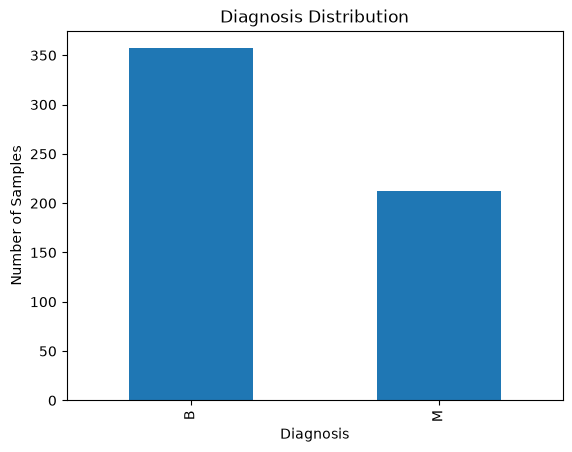

In [18]:
df["diagnosis"].value_counts().plot(kind="bar")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

### Observation
There are two distinct groups in the dataset:
- Benign (B)
- Malignant (M)
The output will not be used while performing PCA because PCA is a **dimensionality reduction technique that does not need output classes**.
We shall make use of the output labels at a later stage to color the two-dimensional plot and observe if the two groups are well-separated.

## Seperate Features and Target 

In [20]:
x=df.drop("diagnosis",axis=1)
y=df["diagnosis"]
print("Features shape:",x.shape)
print("Target shape:",y.shape)

Features shape: (569, 30)
Target shape: (569,)


## Scale the Dataset
The principle of PCA relies on variance.
In case features differ in scales, features having larger values could affect the principal components more strongly.
Therefore, we need to scale the features before using PCA.
StandardScaler will scale the features so that they have:
- Mean = 0
- Standard deviation = 1
We will use StandardScaler for 30 numerical features.

In [21]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print("original shape:",x.shape)
print("scaled shape:",x_scaled.shape)

original shape: (569, 30)
scaled shape: (569, 30)


### Result Analysis
The amount of features remained the same even after scaling.
Before scaling:
- 30 features
After scaling:
- 30 features
Scaling affects only the scale of the numbers but does not affect dimensionality reduction.
The dimensionality reduction step will be performed during PCA application.

## Implementation of PCA
PCA constructs new features, which are referred to as **Principal Components (PCs)**.
Each principal component is a linear combination of the initial features.
The PCs are arranged in terms of the amount of variance that they capture:
- PC1 captures the maximum amount of variance.
- PC2 captures the maximum remaining amount of variance.
- PC3 captures the next maximum amount of variance.
- And so on for all PCs.
The PCs are mutually orthogonal.
At this stage, we will consider all PCs because we need to evaluate the variance captured by each PC.

In [22]:
pca=PCA()
x_pca=pca.fit_transform(x_scaled)
print("Original dimensions:",x_scaled.shape[1])
print("PCA dimensions:",x_pca.shape[1])

Original dimensions: 30
PCA dimensions: 30


#### Explained Variance Ratio

In [23]:
explaiend_variance=pca.explained_variance_ratio_
print(explaiend_variance)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


### Explained Variance Ratio
The explained_variance_ratio_ tells us how much of the total variance is captured by each principal component.
For example, if PC1 has an explained variance ratio of 0.44, then PC1 captures approximately 44% of the total variance.
A larger value means that the component captures more of the variation in the original dataset.

####  Cumulative Explained Variance

In [28]:
cumulative_variance =explaiend_variance.cumsum()
print(cumulative_variance)

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


### Plot Cumulative Explained Variance
The cumulative explained variance helps understand how many variances have been retained if a particular number of components are retained.
For instance:
- 1 component = variance explained by PC1
- 2 components = PC1 + PC2
- 3 components = PC1 + PC2 + PC3
- and so on
We will plot the explained variance of the components.

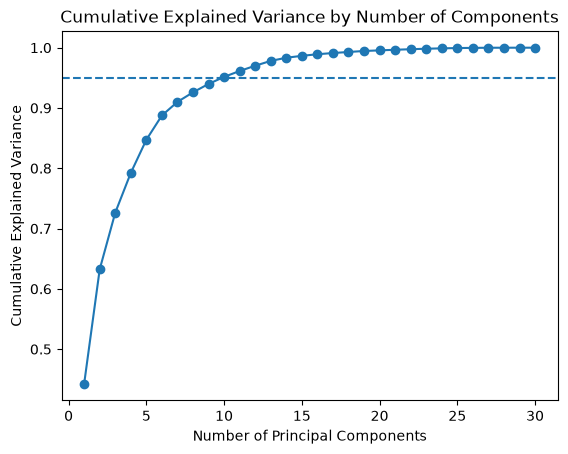

In [29]:
components = range(1, len(cumulative_variance) + 1)
plt.plot(components, cumulative_variance, marker="o")
plt.axhline(y=0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Number of Components")
plt.show()

## Plot Analysis
The explained variance becomes larger as the number of principal components grows.
The horizontal line at the level of 95% is our goal of capturing about 95% of the initial variance.
The intersection point between the explained variance curve and the 95% line shows us approximately how many components are necessary to capture the main information from the initial dataset.

## Selecting the Number of Components
The cumulative explained variance shows how much of the total variance is retained as more principal components are added.
Based on the cumulative explained variance, the first 10 principal components retain approximately 95.16% of the total variance.
Therefore, 10 components were selected because they reduce the feature space from 30 original features to 10 components while preserving approximately 95% of the variance.

In [30]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
variance_95 = cumulative_variance[n_components_95 - 1]
print("Components needed for 95% variance:", n_components_95)
print("Variance retained:", variance_95)

Components needed for 95% variance: 10
Variance retained: 0.9515688143366666


## Result  Explain
We selected the smallest number of principal components that retains at least 95% of the total variance.
This means that we can replace the original 30 features with a smaller number of principal components while preserving approximately 95% of the variation in the dataset.
Therefore, PCA provides a significant reduction in dimensionality with relatively little information loss.

In [34]:
pca_95 = PCA(n_components=n_components_95)
x_pca_95 = pca_95.fit_transform(x_scaled)
print("Original shape:", x.shape)
print("Reduced shape:", x_pca_95.shape)
print("Variance retained:", pca_95.explained_variance_ratio_.sum())

Original shape: (569, 30)
Reduced shape: (569, 10)
Variance retained: 0.9515688143366666


## PCA With Two Components
The most practical use of PCA is visualization.
A human is unable to visualize data in 30 dimensions.
However, we can perform PCA on our dataset and limit ourselves to two principal components:
- PC1
- PC2
Then, we can construct a 2D scatter plot and put observations there.
The diagnosis labels will be used only to color points; they will not be used in PCA itself.

## Reduction of the Dataset into 2 Components
Steps to be followed:
1. Perform PCA with n_components=2.
2. Apply transformation on scaled dataset.
3. Construct a new DataFrame having PC1, PC2 and diagnosis columns.
4. Plot observations in 2D space.
5. Color observations by diagnosis class.

In [35]:
pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(x_scaled)
pca_2d_df = pd.DataFrame(x_pca_2d,columns=["PC1", "PC2"])
pca_2d_df["Diagnosis"] = y.values
pca_2d_df.head()

,PC1,PC2,Diagnosis
0,9.192837,1.948583,M
1,2.387802,-3.768172,M
2,5.733896,-1.075174,M
3,7.122953,10.275589,M
4,3.935302,-1.948072,M


### Variance Explained by PC1 and PC2

In [36]:
print("PC1 variance:", pca_2d.explained_variance_ratio_[0])
print("PC2 variance:", pca_2d.explained_variance_ratio_[1])
print("Total variance retained:", pca_2d.explained_variance_ratio_.sum())

PC1 variance: 0.4427202560752635
PC2 variance: 0.18971182044033075
Total variance retained: 0.6324320765155942


### 2D PCA Scatter Plot

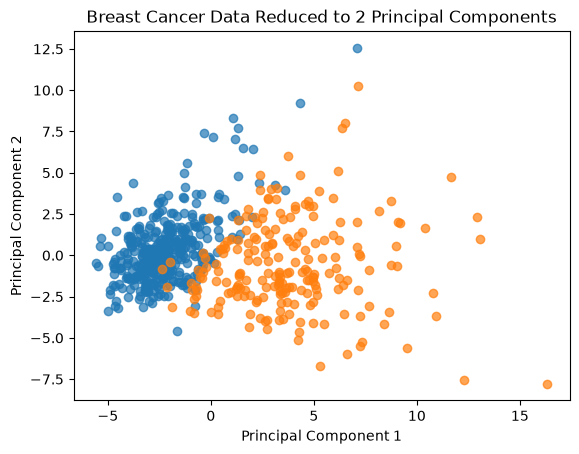

In [37]:
for diagnosis in ["B", "M"]:
    subset = pca_2d_df[pca_2d_df["Diagnosis"] == diagnosis]    
    plt.scatter(subset["PC1"],subset["PC2"],label=diagnosis,alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Data Reduced to 2 Principal Components")
plt.show()

### Plot Analysis
The 2D scatter plot represents the original 30-dimensional dataset using only two dimensions.
Each point represents one observation.
The points are colored according to their known diagnosis:
- B = Benign
- M = Malignant
the two groups appear separated in the PCA plot, this indicates that the first two principal components capture important patterns that distinguish the groups.
However, PCA itself does not know about the diagnosis labels because it is an unsupervised technique.

## What Did PCA Preserve?
PCA preserved the directions of greatest variance in the original dataset.
Instead of keeping the original 30 features separately, PCA created new features called principal components.
These components are combinations of the original features.
By keeping the number of components required for approximately 95% variance, we preserve most of the variation present in the original dataset while using fewer dimensions.

## What Did PCA Keep and at What Price?
### What did PCA keep?
PCA was able to keep approximately 95% of the variance with the use of fewer dimensions compared to the initial 30 features.
### What did PCA cost us?
The most significant price paid for PCA is its **interpretability**.
In the initial data set, there are features that have concrete and understandable meanings like:
- radius
- texture
- perimeter
- area
- concavity
In PCA data set, the features are transformed into:
- PC1
- PC2
- PC3
- ...
Every principal component consists of several original features.
Thus, PCA makes it more difficult to understand the meaning of a certain principal component in terms of original medical measurements.
Also, PCA cannot guarantee that the two-dimensional projection will keep all the patterns from the initial 30-dimensional data set.

## When and When Not to Use PCA?
### PCA can be helpful in situations where:
- The number of numeric features is large.
- There is strong correlation or redundancy between features.
- Computation needs to be made less complex.
- Data visualization is required for high dimensional data.
- Data reduction is needed for more compact representations of the data.
- Some redundancy between correlated features needs to be stripped out.
### PCA might not be suitable in situations where:
- The interpretation of the original features is extremely important.
- Only a small number of features exists.
- Features have not been scaled properly.
- Nonlinear relationships exist that need to be identified.
PCA is also a linear method of dimensionality reduction.

## Final Results
In this notebook, the PCA was successfully implemented on the Breast Cancer Wisconsin dataset.
### Workflow summary
1. Imported and explored the dataset.
2. Dropped ID and redundant columns.
3. Split the feature variables from the diagnosis.
4. Standardized the numerical variables using `StandardScaler`.
5. Performed PCA.
6. Computed the explained variance ratio.
7. Graphed cumulative variance.
8. Defined the smallest number of principal components that will account for around 95% of the variance.
9. Reduced the dataset to two principal components.
10. Visualized in 2D using PC1 and PC2.
11. Used diagnosis labels only for visualization purposes.
12. Elaborated on the pros and cons of PCA.

# Hands-On-Lab -All completed.
All tasks for Day 3 have been completed:
- Step 1: Scale a high-dimensional provided dataset with StandardScaler
The 30 numerical features were standardized using `StandardScaler` so that all features have a comparable scale before applying PCA.
- Step 2: Fit PCA and plot the cumulative explained variance against the number of components.
PCA was fitted on the scaled data, and the cumulative explained variance was plotted to show how the amount of retained information increases as more components are added.
-  Step 3: Choose the number of components that retains ~95% of the variance and justify it.
We identified the minimum number of principal components required to retain approximately 95% of the total variance. This reduced the number of dimensions while preserving most of the information in the original dataset.
-  Step 4: Reduce the data to 2 components and produce a 2D scatter plot, coloring points by a known group
if available.
The original 30 features were reduced to two principal components (PC1 and PC2). A 2D scatter plot was created and colored by diagnosis (Benign/Malignant) to visualize the structure of the data.
-  Step 5: Document what the reduction preserved and what it cost in Markdown
PCA preserved most of the variation in the original dataset while reducing dimensionality. However, interpretability was reduced because the new principal components are combinations of the original features rather than directly meaningful features.
The Jupyter notebook shows the entire process of PCA from preprocessing to interpretation of results.